In [2]:
import matplotlib.pyplot as plt

try:
    plt.style.use('seaborn-whitegrid')
except:
    plt.style.use('seaborn-v0_8-whitegrid')
    
plt.rc('figure', autolayout=True)
plt.rc(
    'axes',
    labelweight='bold',
    labelsize='large',
    titleweight='bold',
    titlesize=18,
    titlepad=10
)


In [4]:
import pandas as pd

red_wine = pd.read_csv('../dataset/wine_quality.csv')
red_wine.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [5]:
red_wine.shape

(55, 12)

## Input Shape

How well can we predict a wine's perceived quality from the physiochemical measurements?

The target is `'quality'`, and the remaining columns are the features. How would you set the `input_shape` parameter for a Keras model on this task?

In [6]:
input_shape = [11]


The input shape for this wine quality dataset is **[11]**.

This is because:

- The dataset has 12 columns total
- 1 column is the target (`'quality'`)
- The remaining **11 columns** are the features (fixed acidity, volatile acidity, citric acid, residual sugar, chlorides, free sulfur dioxide, total sulfur dioxide, density, pH, sulphates, alcohol)

So when creating a Keras model, you would set `input_shape=[11]` or `input_shape=(11,)` for the first layer, indicating that each input sample has 11 features.

## Define a Linear Model

Now define a linear model appropriate for this task. Pay attention to how many inputs and outputs the model should have.

In [8]:
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Dense(units=1, input_shape=input_shape)
])

c:\Users\META\OneDrive\Desktop\kaggle-deep-learning-notes\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Look at the Weights

Internally, Keras represents the weights of a neural network with **tensors**. Tensors are basically TensorFlow's version of a Numpy array with a few differences that make them better suited to deep learning. One of the most important is that tensors are compatible with [GPU](https://www.kaggle.com/docs/efficient-gpu-usage) and [TPU](https://www.kaggle.com/docs/tpu) accelerators. TPUs, in fact, are designed specifically for tensor computations.

A model's weights are kept in its `weights` attribute as a list of tensors. Get the weights of the model you defined above. (If you want, you could display the weights with something like: `print("Weights\n{}\n\nBias\n{}".format(w, b))`).

In [10]:
w,b = model.weights

print("These are the layer weights (after initialization): {}, and the layer bias: {}".format(w,b))

These are the layer weights (after initialization): <Variable path=sequential/dense_1/kernel, shape=(11, 1), dtype=float32, value=[[ 0.6138304 ]
 [-0.17059779]
 [ 0.16657579]
 [-0.69895995]
 [ 0.61532825]
 [ 0.46603626]
 [ 0.5308352 ]
 [-0.6200354 ]
 [ 0.6115156 ]
 [ 0.4383399 ]
 [-0.57530564]]>, and the layer bias: <Variable path=sequential/dense_1/bias, shape=(1,), dtype=float32, value=[0.]>


c:\Users\META\OneDrive\Desktop\kaggle-deep-learning-notes\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step


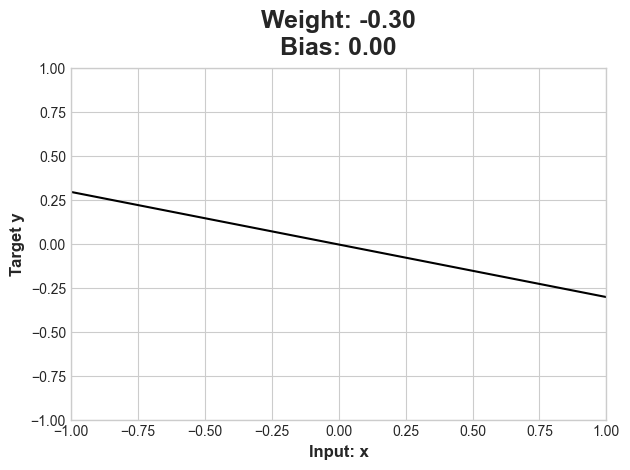

In [11]:
import tensorflow as tf
import matplotlib.pyplot as plt

model = keras.Sequential([
    layers.Dense(1, input_shape=[1]),
])

x = tf.linspace(-1.0, 1.0, 100)
y = model.predict(x)

plt.figure(dpi=100)
plt.plot(x, y, 'k')
plt.xlim(-1, 1)
plt.ylim(-1, 1)
plt.xlabel("Input: x")
plt.ylabel("Target y")
w, b = model.weights # you could also use model.get_weights() here
plt.title("Weight: {:0.2f}\nBias: {:0.2f}".format(w[0][0], b[0]))
plt.show()